In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import xgboost as xgb

RANDOM_STATE = 42
GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
          'jazz', 'metal', 'pop', 'reggae', 'rock']
GENRE_COLORS = dict(zip(GENRES, sns.color_palette('Set2', 10)))

In [69]:
df30 = pd.read_csv('/Users/user/Desktop/Jedha/Projet_Final/Data/features_3_sec.csv')
df3  = pd.read_csv('/Users/user/Desktop/Jedha/Projet_Final/Data/features_3_sec.csv')

In [70]:
feature_cols = [c for c in df30.columns if c not in ['filename', 'label', 'length']]
print(f'{len(feature_cols)} features disponibles :')

mfcc_cols     = [c for c in feature_cols if 'mfcc' in c]
chroma_cols   = [c for c in feature_cols if 'chroma' in c]
spectral_cols = [c for c in feature_cols if 'spectral' in c]
other_cols    = [c for c in feature_cols if c not in mfcc_cols + chroma_cols + spectral_cols]

print(f'  MFCC     : {len(mfcc_cols)} features')
print(f'  Chroma   : {len(chroma_cols)} features')
print(f'  Spectral : {len(spectral_cols)} features')
print(f'  Autres   : {len(other_cols)} features -> {other_cols}')

df30[feature_cols].describe().round(2)

57 features disponibles :
  MFCC     : 40 features
  Chroma   : 2 features
  Spectral : 4 features
  Autres   : 11 features -> ['rms_mean', 'rms_var', 'rolloff_mean', 'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var', 'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo']


,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,...,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00,9990.00
mean,0.38,0.08,0.13,0.00,2199.22,416672.70,2241.39,118271.11,4566.08,1628789.97,...,1.45,49.99,-4.20,51.96,0.74,52.49,-2.50,54.97,-0.92,57.32
std,0.09,0.01,0.07,0.00,751.86,434964.44,543.85,101350.46,1642.07,1489398.21,...,5.74,34.44,5.68,36.40,5.18,38.18,5.11,41.59,5.25,46.44
min,0.11,0.02,0.00,0.00,472.74,811.88,499.16,1183.52,658.34,1145.10,...,-26.85,1.33,-27.81,1.62,-20.73,3.44,-27.45,3.07,-35.64,0.28
25%,0.32,0.08,0.08,0.00,1630.68,123196.13,1887.46,48765.53,3378.31,559551.38,...,-2.23,29.58,-7.95,29.86,-2.52,29.64,-5.73,30.50,-4.00,30.01
50%,0.38,0.09,0.12,0.00,2208.63,265069.21,2230.58,89960.72,4631.38,1160079.60,...,1.46,41.70,-4.44,42.39,0.73,41.83,-2.70,43.44,-1.03,44.33
75%,0.44,0.09,0.18,0.00,2712.58,562415.25,2588.34,158567.35,5591.63,2262437.13,...,5.15,59.27,-0.73,61.68,3.89,62.03,0.51,65.33,2.22,68.21
max,0.75,0.12,0.44,0.03,5432.53,4794118.60,3708.15,1235142.51,9487.45,12983203.77,...,39.14,683.93,34.05,529.36,36.97,629.73,31.37,1143.23,34.21,910.47


In [71]:
le = LabelEncoder()
X = df30[feature_cols].values
y = le.fit_transform(df30['label'])  
class_names = le.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train : {X_train.shape}  |  Test : {X_test.shape}')
print(f'Classes : {list(class_names)}')

Train : (7992, 57)  |  Test : (1998, 57)
Classes : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [72]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, cv=5):
    """Entraine un modele et retourne toutes ses metriques (train + test + CV)."""

    model.fit(X_tr, y_tr)

    y_pred_train = model.predict(X_tr)  
    y_pred       = model.predict(X_te)  

    acc_train = accuracy_score(y_tr, y_pred_train)
    acc_test       = accuracy_score(y_te, y_pred)
    f1        = f1_score(y_te, y_pred, average='macro')
    overfit_gap = acc_train - acc_test  

    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Accuracy  (train)   : {acc_train:.4f}')
    print(f'  Accuracy  (test)    : {acc_test:.4f}    [gap : {overfit_gap:+.4f}]')
    print(f'  F1  (test)    : {f1:.4f}')
    if overfit_gap > 0.1:
        print(f'  Overfitting probable (gap > 0.10)')

    return {
        'model_name': name, 'model': model, 'y_pred': y_pred,
        'accuracy_train': acc_train, 'accuracy_test': acc_test,
        'overfit_gap': overfit_gap, 'f1': f1
    }

results = {}

# Random Forest

In [73]:
rf = RandomForestClassifier(
    n_estimators=300,    
    max_depth=15,      
    min_samples_split=2, 
    random_state=RANDOM_STATE,
    n_jobs=-1            
)

results['Random Forest'] = evaluate_model(
    'Random Forest', rf, X_train, X_test, y_train, y_test
)


  Random Forest
  Accuracy  (train)   : 0.9990
  Accuracy  (test)    : 0.8634    [gap : +0.1356]
  F1  (test)    : 0.8628
  Overfitting probable (gap > 0.10)


# SVM

In [74]:
svm = SVC(
    kernel='rbf',     
    C=10,              
    gamma='scale',     
    probability=True,  
    random_state=RANDOM_STATE
)

results['SVM (RBF)'] = evaluate_model(
    'SVM (RBF)', svm, X_train, X_test, y_train, y_test
)


  SVM (RBF)
  Accuracy  (train)   : 0.9965
  Accuracy  (test)    : 0.9134    [gap : +0.0831]
  F1  (test)    : 0.9133


# XGBoost

In [75]:
xgb_clf = xgb.XGBClassifier(
        n_estimators=300,       
        max_depth=6,            
        learning_rate=0.05,     
        subsample=0.8,         
        colsample_bytree=0.8,   
        use_label_encoder=False,
        eval_metric='mlogloss', 
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
results['XGBoost'] = evaluate_model(
        'XGBoost', xgb_clf, X_train, X_test, y_train, y_test
    )


  XGBoost
  Accuracy  (train)   : 0.9990
  Accuracy  (test)    : 0.8939    [gap : +0.1051]
  F1  (test)    : 0.8939
  Overfitting probable (gap > 0.10)


# Comparaison modèles

In [76]:
results_df = pd.DataFrame([
    {
        'Modele': name,
        'Accuracy (train)': r['accuracy_train'],
        'Accuracy (test)': r['accuracy_test'],
        'Gap (overfit)': r['overfit_gap'],
        'F1 (test)': r['f1']
    }
    for name, r in results.items()
]).sort_values('F1 (test)', ascending=False).reset_index(drop=True)

print('Tableau comparatif :')
display(results_df.style
    .format({'Accuracy (train)': '{:.4f}',
             'Accuracy (test)': '{:.4f}',
             'Gap (overfit)': '{:+.4f}',
             'F1 (test)': '{:.4f}'}))

Tableau comparatif :


,Modele,Accuracy (train),Accuracy (test),Gap (overfit),F1 (test)
0,SVM (RBF),0.9965,0.9134,+0.0831,0.9133
1,XGBoost,0.9990,0.8939,+0.1051,0.8939
2,Random Forest,0.9990,0.8634,+0.1356,0.8628


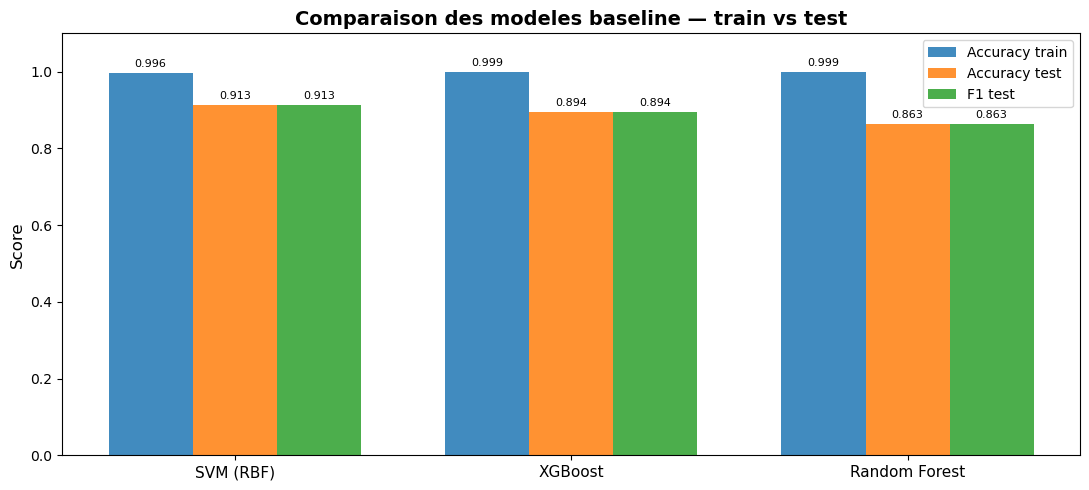

In [77]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
width = 0.25

bars0 = ax.bar(x - width, results_df['Accuracy (train)'],
                width, label='Accuracy train', alpha=0.85)
bars1 = ax.bar(x,          results_df['Accuracy (test)'],
                width, label='Accuracy test', alpha=0.85)
bars2 = ax.bar(x + width,  results_df['F1 (test)'],
                width, label='F1 test', alpha=0.85)

for bars in [bars0, bars1, bars2]:
    ax.bar_label(bars, fmt='{:.3f}', padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Modele'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Comparaison des modeles baseline — train vs test', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Analyse meilleur modèle

In [78]:
best_name = results_df.iloc[0]['Modele']  
best = results[best_name]
print(f'Meilleur modele : {best_name}')

Meilleur modele : SVM (RBF)


In [79]:
print(classification_report(
    y_test, best['y_pred'],
    target_names=class_names
))

              precision    recall  f1-score   support

       blues       0.90      0.94      0.92       200
   classical       0.92      0.98      0.95       199
     country       0.87      0.86      0.87       199
       disco       0.88      0.88      0.88       200
      hiphop       0.93      0.91      0.92       200
        jazz       0.92      0.94      0.93       200
       metal       0.98      0.95      0.97       200
         pop       0.94      0.86      0.90       200
      reggae       0.90      0.92      0.91       200
        rock       0.90      0.90      0.90       200

    accuracy                           0.91      1998
   macro avg       0.91      0.91      0.91      1998
weighted avg       0.91      0.91      0.91      1998



# Dataset 3s

In [80]:
feature_cols_3 = [c for c in df3.columns if c not in ['filename', 'label', 'length']]
df3['clip_id'] = df3['filename'].apply(lambda x: x.split('.')[0] + '.' + x.split('.')[1])

unique_clips = df3['clip_id'].unique()
np.random.seed(RANDOM_STATE)
n_test_clips = int(len(unique_clips) * 0.2)
test_clips   = np.random.choice(unique_clips, size=n_test_clips, replace=False)

# Toutes les fenetres d'un clip sont soit dans train, soit dans test — jamais les deux
train_mask = ~df3['clip_id'].isin(test_clips)
test_mask  =  df3['clip_id'].isin(test_clips)

X_train3 = df3.loc[train_mask, feature_cols_3].values
X_test3  = df3.loc[test_mask,  feature_cols_3].values
y_train3 = le.transform(df3.loc[train_mask, 'label'])
y_test3  = le.transform(df3.loc[test_mask,  'label'])

sc_3 = StandardScaler()
X_train3 = sc_3.fit_transform(X_train3)
X_test3  = sc_3.transform(X_test3)

print(f'Train 3s : {X_train3.shape}  |  Test 3s : {X_test3.shape}')

Train 3s : (7993, 57)  |  Test 3s : (1997, 57)


In [82]:
svm3 = SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE)
svm3.fit(X_train3, y_train3)
y_pred3 = svm3.predict(X_test3)

acc_train3 = accuracy_score(y_train3, svm3.predict(X_train3))
acc_test3 = accuracy_score(y_test3, y_pred3)
f1_3 = f1_score(y_test3, y_pred3, average='macro')

print('SVM sur features 3s :')
print(f'  Accuracy train : {acc_train3:.4f}')
print(f'  Accuracy test  : {acc_test3:.4f}    [gap : {acc_train3 - acc_test3:+.4f}]')
print(f'  F1             : {f1_3:.4f}')
print(f'\nSVM sur features 30s :')
print(f'  Accuracy train : {results["SVM (RBF)"]["accuracy_train"]:.4f}')
print(f'  Accuracy test  : {results["SVM (RBF)"]["accuracy_test"]:.4f}')
print(f'  F1             : {results["SVM (RBF)"]["f1"]:.4f}')

SVM sur features 3s :
  Accuracy train : 0.9976
  Accuracy test  : 0.7081    [gap : +0.2896]
  F1             : 0.6985

SVM sur features 30s :
  Accuracy train : 0.9965
  Accuracy test  : 0.9134
  F1             : 0.9133
